In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

In [96]:
repo_root = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
base_path = repo_root / "data" / "averaged"
print("Base path resolved to:", base_path)
files = list(base_path.glob("**/*_inavg.csv"))
if not files:
    raise FileNotFoundError(f"No *_inavg.csv files found under {base_path}")

# ---- Load participant data ---- #
participant_dfs = {}
for file in files:
    name = file.parent.name.title()
    df = pd.read_csv(file)
    participant_dfs[name] = df

# ---- Build RT matrix ---- #
in_rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    rt_col = [col for col in df.columns if col.lower() != "gap"][0]
    rt_values = df[rt_col].values.squeeze()  # ensure 1D
    in_rt_matrix.append(rt_values)
    participant_names.append(name)

in_rt_matrix = np.vstack(in_rt_matrix) 

print("RT matrix shape:", in_rt_matrix.shape)

files = list(base_path.glob("**/*_outavg.csv"))
if not files:
    raise FileNotFoundError(f"No *_outavg.csv files found under {base_path}")
# ---- Out of Tune RT Matrix ---- #
out_rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    rt_col = [col for col in df.columns if col.lower() != "gap"][0]
    rt_values = df[rt_col].values.squeeze()  # ensure 1D
    out_rt_matrix.append(rt_values)
    participant_names.append(name)

out_rt_matrix = np.vstack(out_rt_matrix) 

print("RT matrix shape:", out_rt_matrix.shape)

Base path resolved to: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
RT matrix shape: (11, 46)
RT matrix shape: (11, 46)


### PCA
- When you run PCA, you're transforming your original features into new "principal components" (PCs).

- Each principal component explains a certain amount of the total variance (information) in your data.

- Explained Variance Ratio = Variance explained by a PC / Total variance in the data

- "How much information (variance) from the original data is captured by this particular principal component?"

### Elbow Curve (In-Tune RTs)

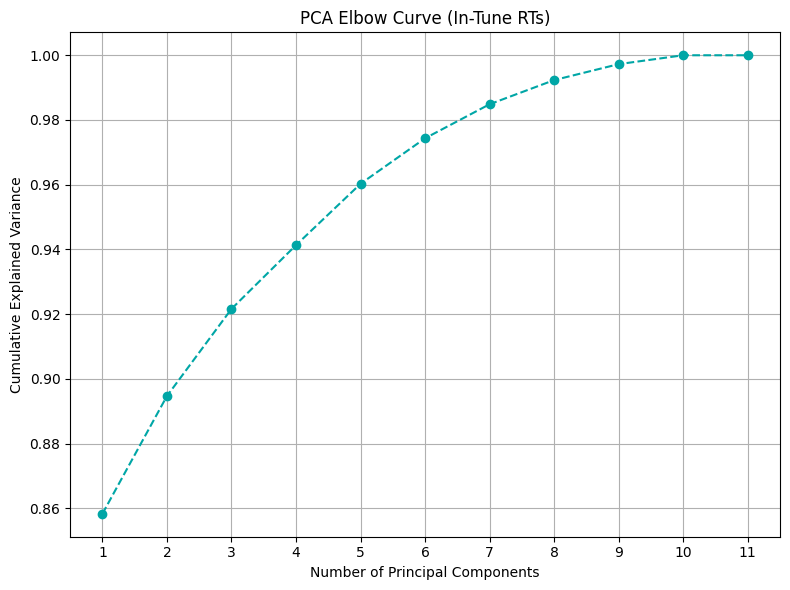

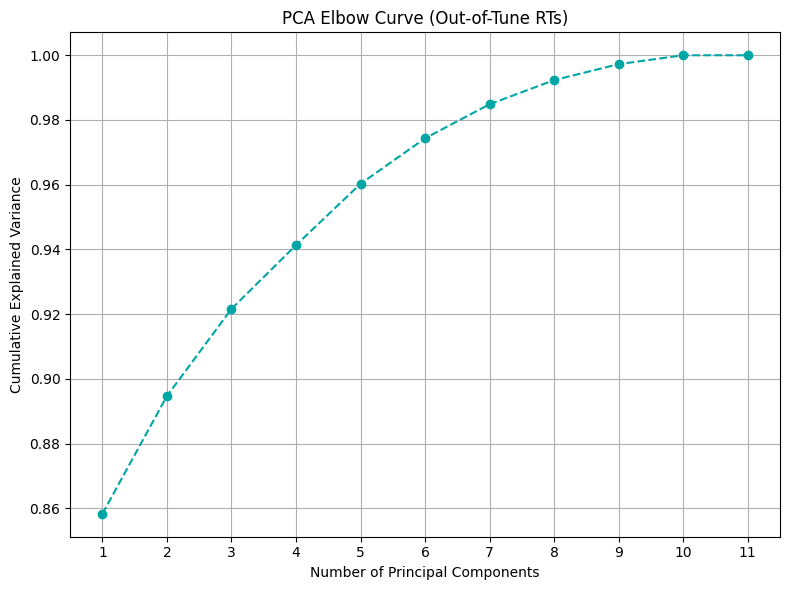

In [97]:
pca = PCA()
pca.fit(in_rt_matrix)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
#### plot ####
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color="#00A6A6")
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Curve (In-Tune RTs)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA()
pca.fit(out_rt_matrix)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color="#00A6A6")
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Curve (Out-of-Tune RTs)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()


Explained variance ratio: [0.85833588 0.03638143]


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_21387/2446329301.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)


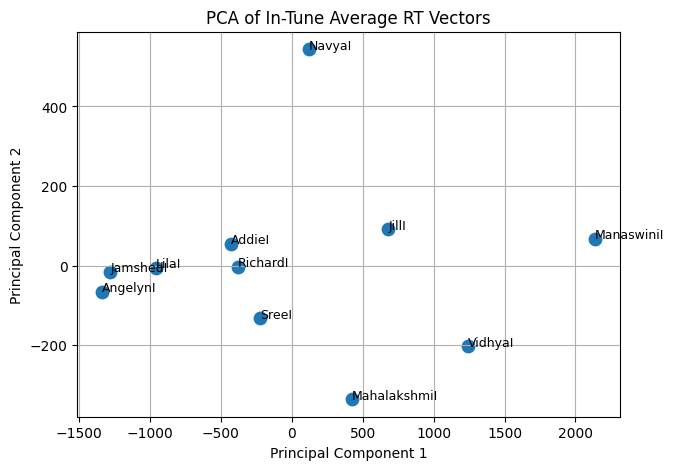

In [98]:
# ---- PCA ---- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(in_rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=participant_names)
print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# plot pca
plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=80)
for i, name in enumerate(participant_names):
    name = name + "I"
    plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of In-Tune Average RT Vectors")
plt.grid(True)
plt.show()


Explained variance ratio: [0.85833588 0.03638143 0.02691511]
Total variance explained: 0.9216324216735184


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_21387/3567510852.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)


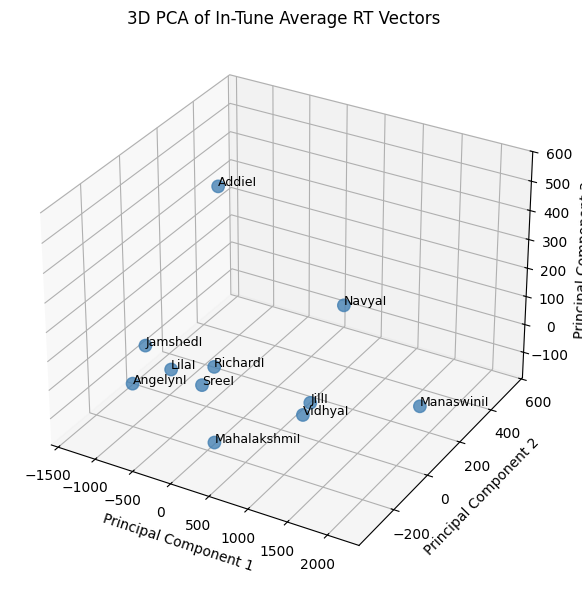

In [99]:
# ---- PCA (3D) ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(in_rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"], index=participant_names)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# ---- 3D Plot ---- #
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], s=80, c="steelblue", alpha=0.8)

# Label each participant
for i, name in enumerate(participant_names):
    name = name + "I"
    ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA of In-Tune Average RT Vectors")
plt.tight_layout()
plt.show()


Explained variance ratio: [0.85833588 0.03638143]


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_21387/291974995.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)


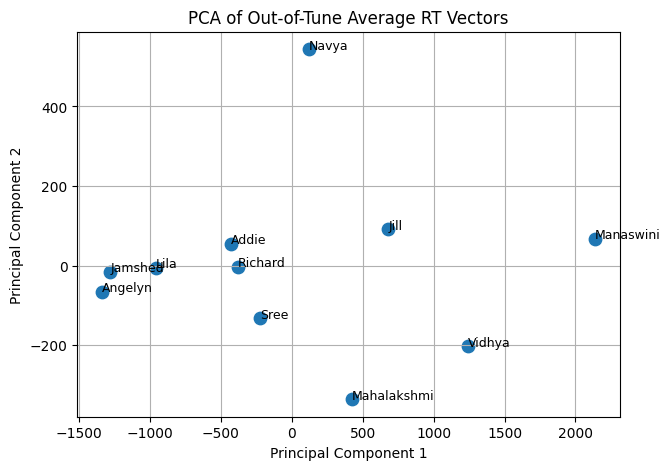

In [100]:
# ---- PCA ---- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(out_rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=participant_names)
print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# plot pca
plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=80)
for i, name in enumerate(participant_names):
    plt.text(pca_df["PC1"][i] + 0.01, pca_df["PC2"][i], name, fontsize=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Out-of-Tune Average RT Vectors")
plt.grid(True)
plt.show()


Explained variance ratio: [0.85833588 0.03638143 0.02691511]
Total variance explained: 0.9216324216735184


/var/folders/3q/7y_0d44d3d17xy40wq2ppmww0000gn/T/ipykernel_21387/1158617188.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)


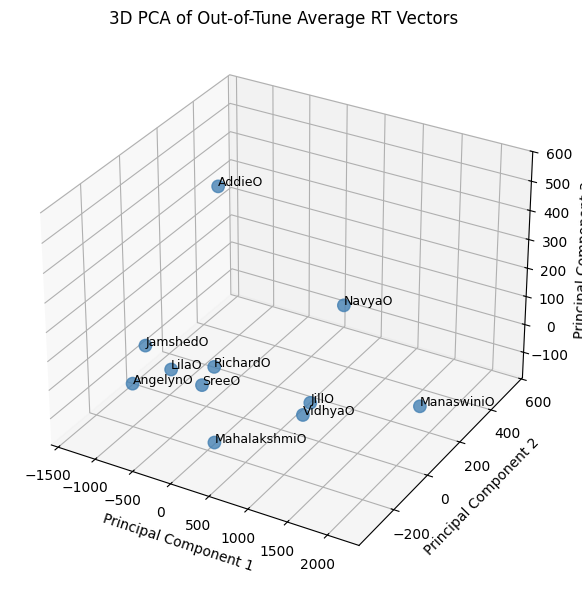

In [101]:

# ---- PCA (3D) ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(out_rt_matrix)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"], index=participant_names)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# ---- 3D Plot ---- #
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], s=80, c="steelblue", alpha=0.8)

# Label each participant
for i, name in enumerate(participant_names):
    name = name + "O"
    ax.text(pca_df["PC1"][i], pca_df["PC2"][i], pca_df["PC3"][i], name, fontsize=9)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA of Out-of-Tune Average RT Vectors")
plt.tight_layout()
plt.show()

In [102]:
base_path = Path.cwd().parent
averaged_dir = base_path / "data" / "averaged"

# ---- COLLECT PARTICIPANTS ---- #
participants = [f.name for f in averaged_dir.iterdir() if f.is_dir()]
participants.sort()
print(f"Found {len(participants)} participants:", participants)

combined_rt_matrix = []
combined_names = []

# ---- BUILD MATRIX ---- #
for name in participants:
    participant_dir = averaged_dir / name
    in_file = participant_dir / f"{name}_inavg.csv"
    out_file = participant_dir / f"{name}_outavg.csv"
    
    if not in_file.exists() or not out_file.exists():
        continue
    
    try:
        in_df = pd.read_csv(in_file)
        out_df = pd.read_csv(out_file)
    except Exception as e:
        continue
    
    # Identify RT columns dynamically
    in_col = next((col for col in in_df.columns if "InAveRT" in col), None)
    out_col = next((col for col in out_df.columns if "OutAveRT" in col), None)
    
    if not in_col or not out_col:
        continue
    
    in_rt = in_df[in_col].values
    out_rt = out_df[out_col].values

    combined_rt_matrix.append(in_rt)
    combined_names.append(name.title() + "_In")

    combined_rt_matrix.append(out_rt)
    combined_names.append(name.title() + "_Out")

# ---- CONVERT TO NUMPY ---- #
combined_rt_matrix = np.vstack(combined_rt_matrix)
print(f"\nRT matrix shape: {combined_rt_matrix.shape}")

Found 13 participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']

RT matrix shape: (22, 46)


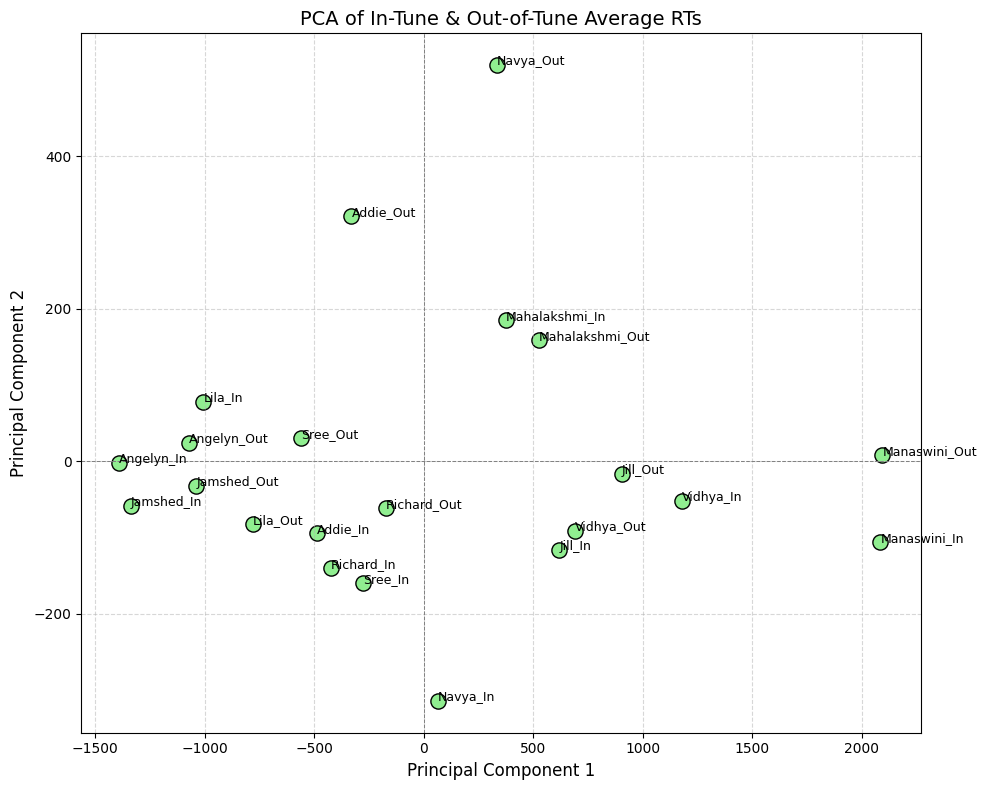

In [103]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Perform PCA on the combined RT matrix (In-Tune + Out-of-Tune)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_rt_matrix)

# Create DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = combined_names  # Eg. ['AngelynI', 'AngelynO', ...]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=120, color='lightgreen', edgecolor='black')

# Annotate points
for _, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.title('PCA of In-Tune & Out-of-Tune Average RTs', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

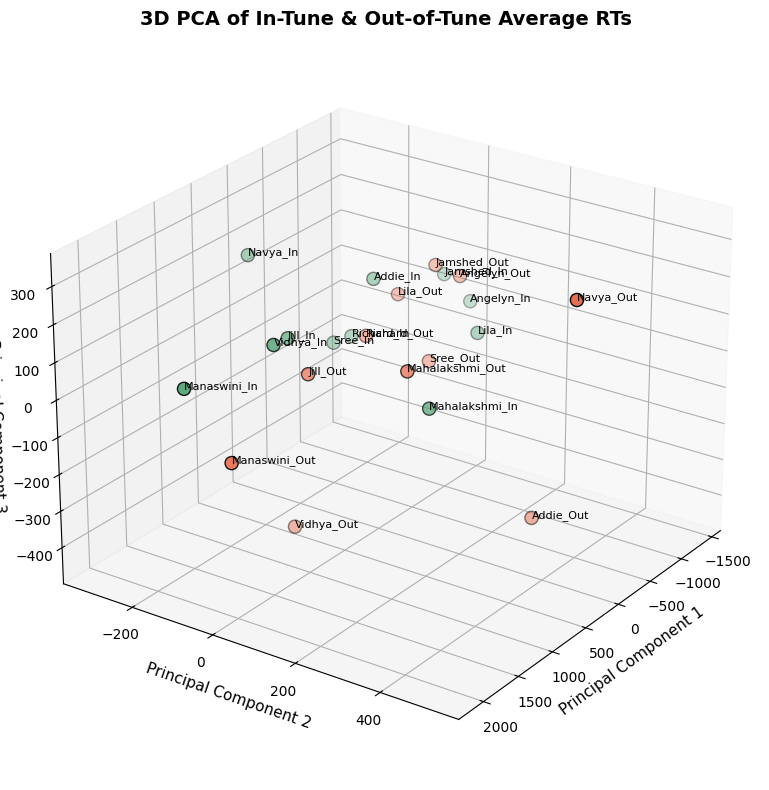

Explained variance ratio: [0.8207 0.0254 0.0228]
Cumulative variance explained: 0.8689950646438884


In [104]:
# ---- Perform PCA on the combined RT matrix ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(combined_rt_matrix)

# ---- Create DataFrame for plotting ---- #
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Participant'] = combined_names  # e.g., ['Angelyn_In', 'Angelyn_Out', ...]

# ---- Plot 3D PCA ---- #
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color points based on In-Tune vs Out-of-Tune
colors = ['#4C9F70' if 'In' in name else '#E76F51' for name in pca_df['Participant']]

ax.scatter(
    pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
    s=90, c=colors, edgecolor='black'
)

# Annotate points close to their dots
for _, row in pca_df.iterrows():
    ax.text(
        row['PC1'] + 0.0005,  # small offset so label hugs the point
        row['PC2'] + 0.0005,
        row['PC3'] + 0.0005,
        row['Participant'],
        fontsize=8
    )

# ---- Axes labels and title ---- #
ax.set_xlabel('Principal Component 1', fontsize=11)
ax.set_ylabel('Principal Component 2', fontsize=11)
ax.set_zlabel('Principal Component 3', fontsize=11)
ax.set_title('3D PCA of In-Tune & Out-of-Tune Average RTs', fontsize=14, weight='bold')

# ---- Grid & view ---- #
ax.grid(True, alpha=0.3)
ax.view_init(elev=25, azim=35)  # adjust viewing angle if needed
plt.tight_layout()
plt.show()

# ---- Explained variance ---- #
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative variance explained:", np.sum(pca.explained_variance_ratio_))

In [105]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---- Define base path ---- #
base_path = Path.cwd().parent
averaged_dir = base_path / "data" / "averaged"

# ---- Collect participants ---- #
participants = [f.name for f in averaged_dir.iterdir() if f.is_dir()]
participants.sort()
print(f"Found {len(participants)} participants:", participants)

combined_rt_matrix = []
combined_names = []

# ---- Build matrix ---- #
for name in participants:
    participant_dir = averaged_dir / name
    combined_file = participant_dir / f"{name}_combinedavg.csv"

    if not combined_file.exists():
        print(f"⚠️ Missing file for {name}")
        continue

    try:
        df = pd.read_csv(combined_file)
    except Exception as e:
        print(f"❌ Error reading {name}: {e}")
        continue

    # Identify the combined RT column dynamically
    combined_col = next(
        (col for col in df.columns if f"{name}CombinedAveRT" in col),
        None
    )

    if not combined_col:
        print(f"⚠️ No 'combinedAveRT' column found for {name}")
        continue

    rt_values = df[combined_col].values
    combined_rt_matrix.append(rt_values)
    combined_names.append(name.title())

# ---- Convert to NumPy ---- #
combined_rt_matrix = np.array(combined_rt_matrix)
print(f"\n✅ RT matrix shape: {combined_rt_matrix.shape}")
print(f"Participants processed: {len(combined_names)}")


Found 13 participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
⚠️ Missing file for all_combined
⚠️ Missing file for combined

✅ RT matrix shape: (11, 46)
Participants processed: 11


Explained variance (%): PC1=89.89, PC2=2.64


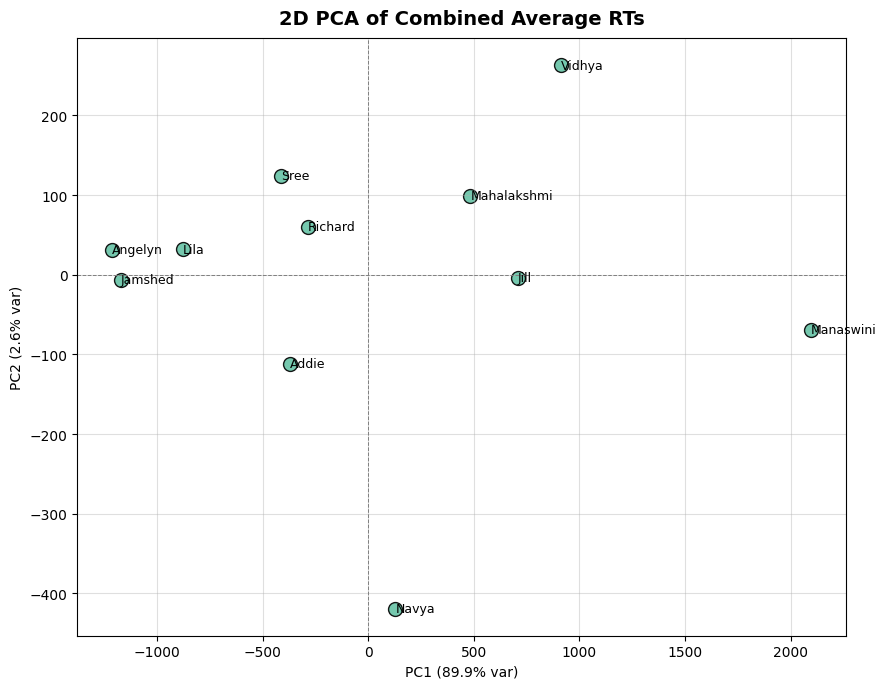

In [106]:
# ---- Run PCA ---- #
pca_2d = PCA(n_components=2)
pca_result_2d = pca_2d.fit_transform(combined_rt_matrix)

# ---- Create DataFrame ---- #
pca_df_2d = pd.DataFrame(pca_result_2d, columns=["PC1", "PC2"])
pca_df_2d["Participant"] = combined_names

# ---- Explained variance ---- #
explained = pca_2d.explained_variance_ratio_ * 100
print(f"Explained variance (%): PC1={explained[0]:.2f}, PC2={explained[1]:.2f}")

# ---- Plot ---- #
plt.figure(figsize=(9, 7))
plt.scatter(
    pca_df_2d["PC1"],
    pca_df_2d["PC2"],
    s=100,
    color="#66c2a5",
    edgecolor="black",
    alpha=0.9
)

# ---- Add participant labels tightly ---- #
for _, row in pca_df_2d.iterrows():
    plt.text(
        row["PC1"] + 0.005,
        row["PC2"] + 0.005,
        row["Participant"],
        fontsize=9,
        ha='left',
        va='center',
        color='black'
    )

# ---- Style ---- #
plt.title("2D PCA of Combined Average RTs", fontsize=14, weight="bold", pad=10)
plt.xlabel(f"PC1 ({explained[0]:.1f}% var)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% var)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Explained variance (%): PC1=89.89, PC2=2.64, PC3=1.87


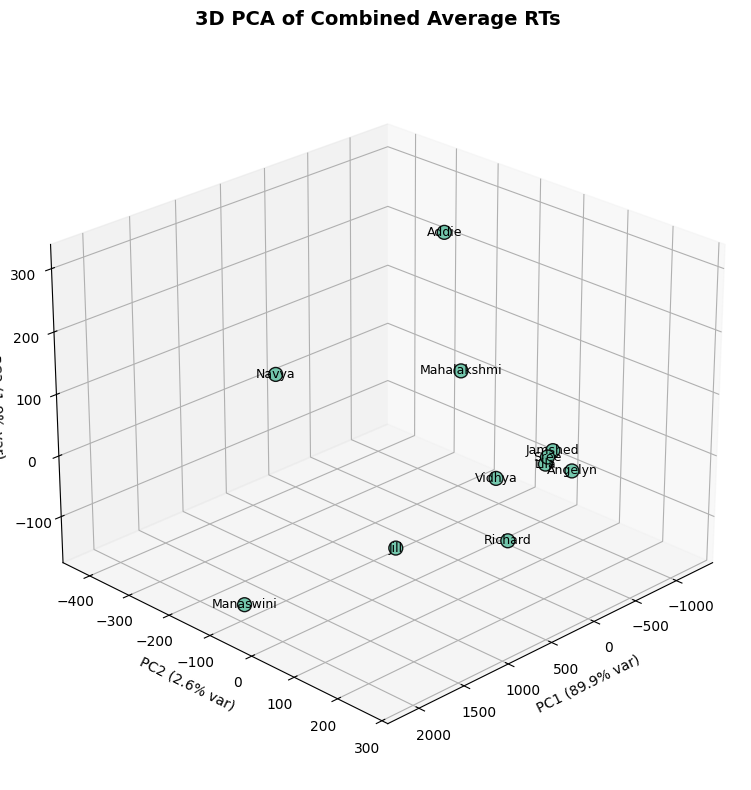

In [107]:
# ---- Run PCA ---- #
pca = PCA(n_components=3)
pca_result = pca.fit_transform(combined_rt_matrix)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"])
pca_df["Participant"] = combined_names

# ---- Explained variance ---- #
explained = pca.explained_variance_ratio_ * 100
print(f"Explained variance (%): PC1={explained[0]:.2f}, PC2={explained[1]:.2f}, PC3={explained[2]:.2f}")

# ---- Plot in 3D ---- #
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(
    pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
    s=100, color="#66c2a5", edgecolor="black", alpha=0.9
)

# Add participant labels close to dots
for _, row in pca_df.iterrows():
    ax.text(
        row["PC1"], row["PC2"], row["PC3"],
        row["Participant"],
        fontsize=9,
        ha='center',
        va='center',
        color='black'
    )

# ---- Style the plot ---- #
ax.set_title("3D PCA of Combined Average RTs", fontsize=14, weight="bold", pad=20)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% var)")
ax.set_zlabel(f"PC3 ({explained[2]:.1f}% var)")
ax.grid(True, alpha=0.3)

# Adjust view angle
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

/Users/vidhyakshayakannan/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


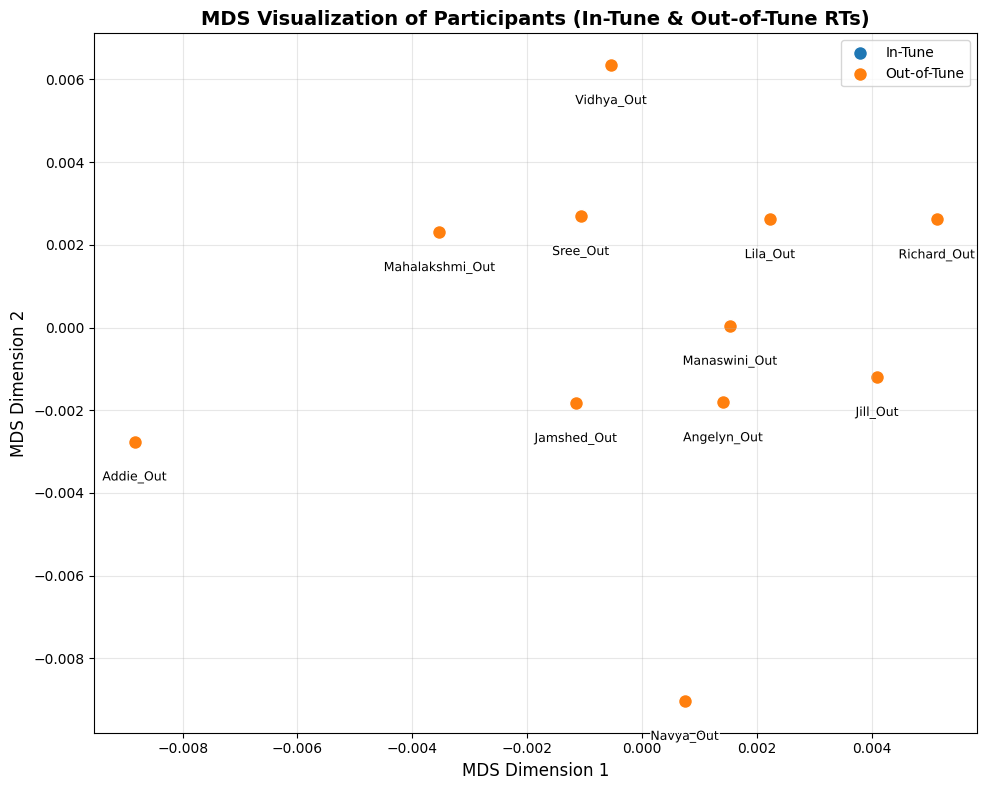

In [108]:
import matplotlib.patheffects as path_effects
# ---- Compute Distance Matrix ---- #
distance_matrix = 1 - cosine_similarity(combined_rt_matrix)

# ---- Perform MDS ---- #
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_coords = mds.fit_transform(distance_matrix)

# ---- Separate In and Out ---- #
in_points, out_points = {}, {}
for i, name in enumerate(combined_names):
    base = name.replace("_In", "").replace("_Out", "")
    if "_In" in name:
        in_points[base] = mds_coords[i]
    else:
        out_points[base] = mds_coords[i]

# ---- Plot ---- #
plt.figure(figsize=(10, 8))
plt.scatter(
    [p[0] for p in in_points.values()],
    [p[1] for p in in_points.values()],
    color="#1f77b4",
    s=100,
    label="In-Tune",
    edgecolor="white",
    linewidth=1,
)
plt.scatter(
    [p[0] for p in out_points.values()],
    [p[1] for p in out_points.values()],
    color="#ff7f0e",
    s=100,
    label="Out-of-Tune",
    edgecolor="white",
    linewidth=1,
)
for name, coords in in_points.items():
    plt.text(
        coords[0], coords[1] + 0.0007,
        name + "_In",
        fontsize=9, ha='center', va='bottom',
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
    )

for name, coords in out_points.items():
    plt.text(
        coords[0], coords[1] - 0.0007,
        name + "_Out",
        fontsize=9, ha='center', va='top',
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
    )
plt.title("MDS Visualization of Participants (In-Tune & Out-of-Tune RTs)", fontsize=14, weight='bold')
plt.xlabel("MDS Dimension 1", fontsize=12)
plt.ylabel("MDS Dimension 2", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()
